In [ ]:
!pip install pandas numpy matplotlib seaborn tsfel tslearn scikit-learn imbalanced-learn xgboost jupyter

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Pengaturan visual agar grafik terlihat elegan ala publikasi paper
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})
warnings.filterwarnings('ignore')

print("✅ Library EDA berhasil dimuat!")

✅ Library EDA berhasil dimuat!


In [5]:
# Setup Jalur File Raw
base_dir = os.getcwd()
raw_data_path = os.path.join(base_dir, 'Data', 'Raw', 'dailyData.csv')

# Mapping 9 Kolom Emas + Identitas
column_mapping = {
    'Well_ID': 'Well_ID',
    'DOWN_TIME_HOURS': 'Downtime',
    'ESP Data - Output Frequency': 'Freq',
    'ESP Data - Drive Current': 'Current',
    'ESP Data - Vibration X': 'Vibration',
    'ESP Data - Intake Pressure': 'Intake_Press',
    'ESP Data - Motor Winding Temperature': 'Motor_Temp',
    'Gas_Saturation_in_Pump': 'Gas_Sat',
    'Pump_Delta_Pressure': 'Delta_Press',
    'Power_Difference': 'Pwr_Diff',
    'Liquid_Intake': 'Liq_Intake'
}

# Memuat data
df_eda = pd.read_csv(r'C:\Users\hatta\ESP-FAILURE-DETECTION\Data\Raw\dailyData.csv', usecols=column_mapping.keys())
df_eda = df_eda.rename(columns=column_mapping)

# Membuat kolom Target Biner untuk mempermudah visualisasi
# 1 = Anomali/Rusak, 0 = Normal
df_eda['Is_Anomaly'] = df_eda['Downtime'].apply(lambda x: 1 if x > 0 else 0)

print(f"Data termuat: {df_eda.shape[0]} baris.")
display(df_eda.head())

Data termuat: 50056 baris.


,Downtime,Current,Intake_Press,Motor_Temp,Freq,Vibration,Liq_Intake,Delta_Press,Gas_Sat,Pwr_Diff,Well_ID,Is_Anomaly
0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,345,1
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,345,0
2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,345,0
3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,345,0
4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,345,0


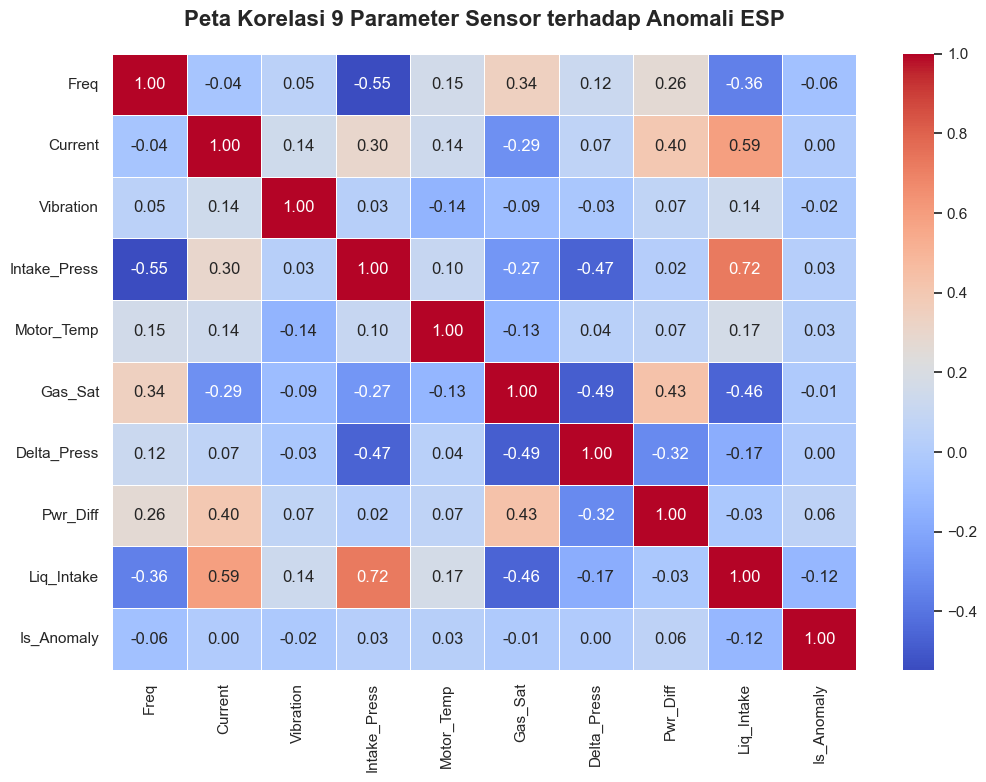

In [13]:
plt.figure(figsize=(12, 8))

# Menghitung korelasi (hanya untuk kolom angka, abaikan Well_ID)
cols_to_corr = [
    'Freq', 'Current', 'Vibration', 'Intake_Press', 
    'Motor_Temp', 'Gas_Sat', 'Delta_Press', 'Pwr_Diff', 'Liq_Intake', 'Is_Anomaly'
]

# Plot Heatmap
corr_matrix = df_eda[cols_to_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Peta Korelasi 9 Parameter Sensor terhadap Anomali ESP", pad=20, fontsize=16, fontweight='bold')
plt.savefig('C:\\Users\\hatta\\ESP-FAILURE-DETECTION\\Reports\\heatmap_korelasi.png', dpi=300, bbox_inches='tight')
plt.show()


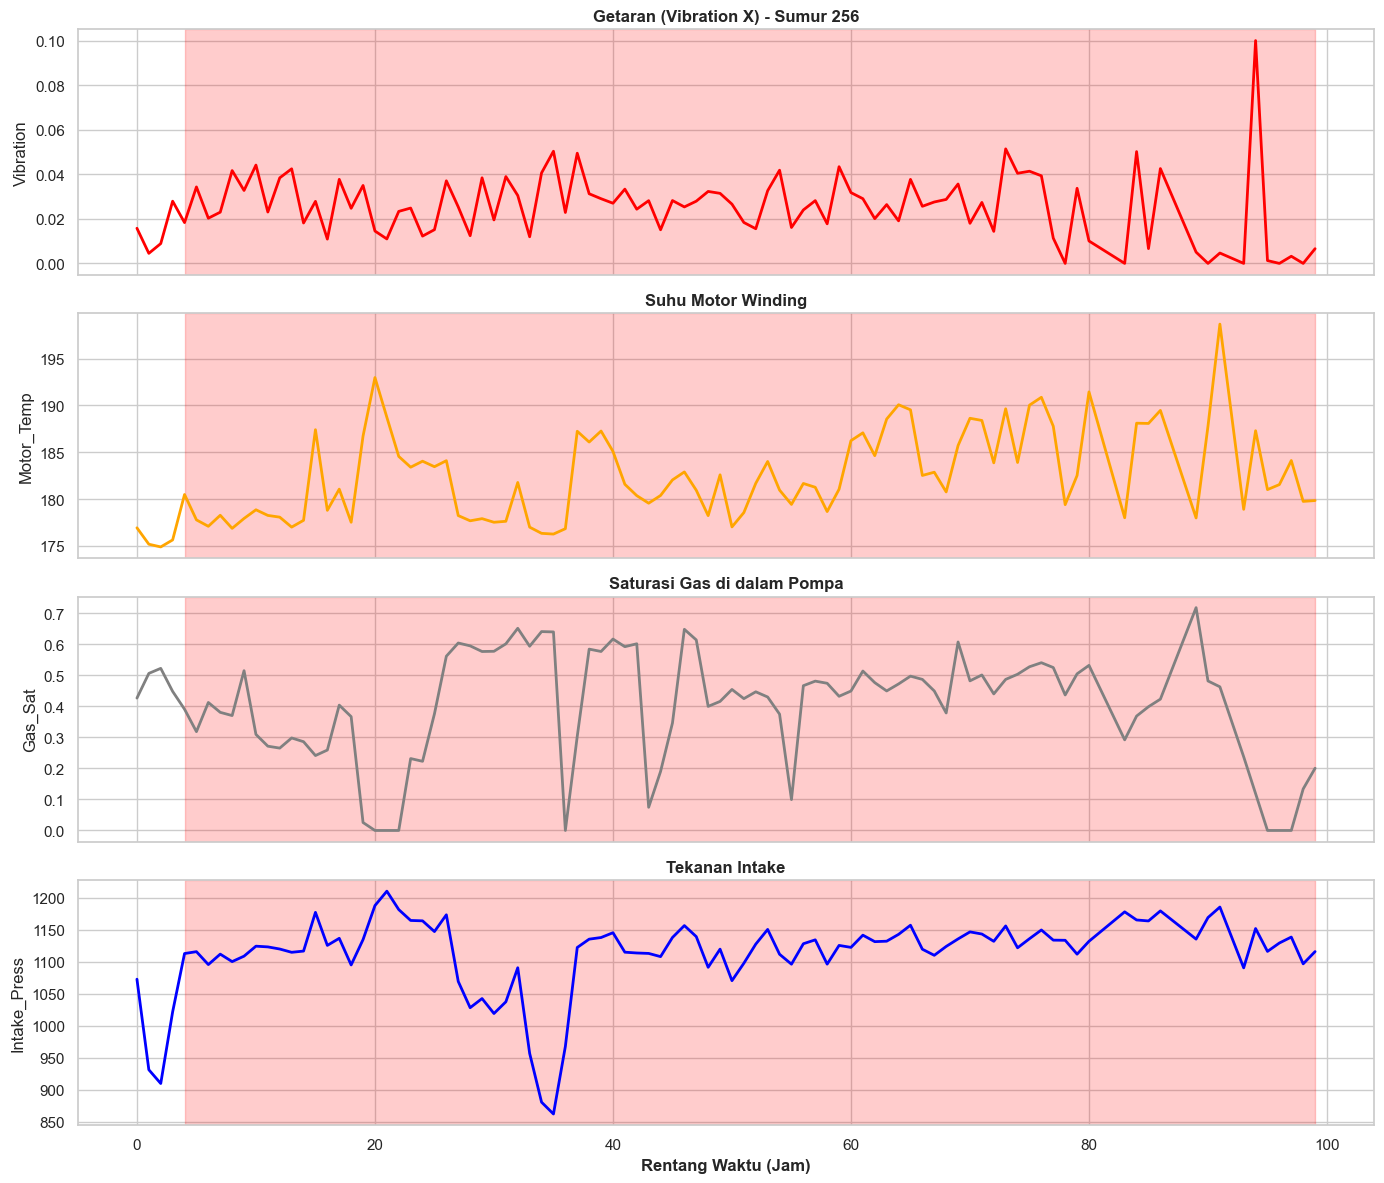

In [7]:
# Kita ambil contoh satu sumur secara acak (ganti Well_ID sesuai data Anda)
# Misal kita ambil sumur yang memiliki riwayat Downtime terbanyak
sumur_rusak = df_eda[df_eda['Is_Anomaly'] == 1]['Well_ID'].value_counts().index[0]

# Ambil 100 baris terakhir dari sumur tersebut (momen-momen kritis sebelum mati)
df_sample = df_eda[df_eda['Well_ID'] == sumur_rusak].tail(100).reset_index()

# Kita plot 4 sensor paling kritis untuk melihat "Tarian Kematian" mesin ESP
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

sns.lineplot(ax=axes[0], data=df_sample, x=df_sample.index, y='Vibration', color='red', linewidth=2)
axes[0].set_title(f"Getaran (Vibration X) - Sumur {sumur_rusak}", fontweight='bold')

sns.lineplot(ax=axes[1], data=df_sample, x=df_sample.index, y='Motor_Temp', color='orange', linewidth=2)
axes[1].set_title("Suhu Motor Winding", fontweight='bold')

sns.lineplot(ax=axes[2], data=df_sample, x=df_sample.index, y='Gas_Sat', color='gray', linewidth=2)
axes[2].set_title("Saturasi Gas di dalam Pompa", fontweight='bold')

sns.lineplot(ax=axes[3], data=df_sample, x=df_sample.index, y='Intake_Press', color='blue', linewidth=2)
axes[3].set_title("Tekanan Intake", fontweight='bold')

# Menandai area di mana mesin akhirnya mati (Downtime > 0)
for ax in axes:
    ax.axvspan(df_sample[df_sample['Is_Anomaly'] == 1].index.min(), 
               df_sample.index.max(), color='red', alpha=0.2, label='Fase Mesin Mati')

plt.xlabel("Rentang Waktu (Jam)", fontweight='bold')
plt.tight_layout()
plt.show()

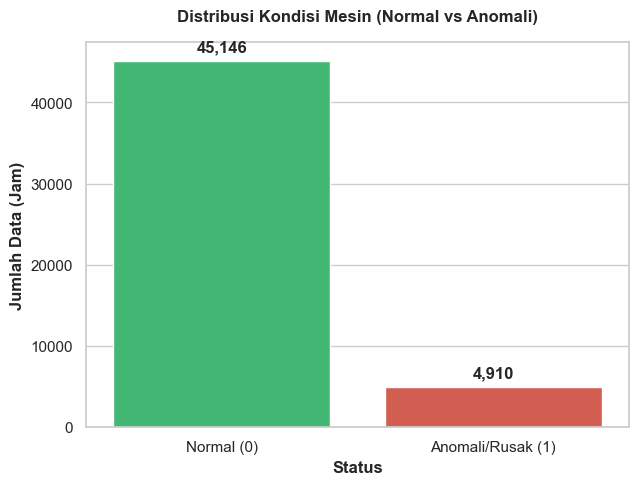

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_eda, x='Is_Anomaly', palette=['#2ecc71', '#e74c3c'])

plt.title("Distribusi Kondisi Mesin (Normal vs Anomali)", pad=15, fontweight='bold')
plt.xlabel("Status", fontweight='bold')
plt.ylabel("Jumlah Data (Jam)", fontweight='bold')
ax.set_xticklabels(['Normal (0)', 'Anomali/Rusak (1)'])

# Menambahkan angka di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.show()

